<a href="https://colab.research.google.com/github/Akira006/noise-aware-federated-learning-dr/blob/main/Notebook/MobileNetV2/exp2_fedavg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experiment 2 — Standard Federated Learning (FedAvg)
**Project:** Noise-Aware Federated Learning for Robust Diabetic Retinopathy Classification  
**Model:** MobileNetV2 | **Paradigm:** Standard FedAvg — 3 clients, NO noise augmentation

| Config | Value |
|--------|-------|
| Clients | DDR, EyePACS, APTOS |
| Communication Rounds | 20 (rounds 1-10 frozen, 11-20 unfrozen) |
| Local Epochs / Round | 5 |
| Aggregation | Dataset-size-weighted FedAvg |
| Noise aug (training) | ❌ None |
| Test | Clean + Noisy (seed=123, identik di 3 notebook) |

> ⚠️ **JANGAN ubah `SEED` dan `NOISY_TEST_SEED`** — harus konsisten di 3 notebook.

## 1. GPU Check

In [1]:
!nvidia-smi

Mon Jun  8 08:59:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   37C    P0             53W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# Cell 1 — GPU Setup (taruh sebelum semua import)
import os
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"  # lebih stable di G4/L4
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✓ GPU: {gpus[0].name}")
    print(f"✓ TF version: {tf.__version__}")
else:
    print("No GPU detected")

✓ GPU: /physical_device:GPU:0
✓ TF version: 2.20.0


## 2. Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# GPU Memory Growth — prevent CUDA_ERROR_INVALID_HANDLE
import os
os.environ["TF_FORCE_GPU_ALLOW_GROWTH"] = "true"

import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU memory growth enabled: {len(gpus)} GPU(s)")

GPU memory growth enabled: 1 GPU(s)


## 3. Imports

In [5]:
import os, json, random, time, gc, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from tqdm.notebook import tqdm

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score, roc_curve, auc, cohen_kappa_score
)
from sklearn.preprocessing import label_binarize

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 4. Configuration

In [6]:
# ── REPRODUCIBILITY (sama di 3 notebook) ─────────────────────────
SEED             = 42
NOISY_TEST_SEED  = 123
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ── MODEL & EXPERIMENT ────────────────────────────────────────────
MODEL_NAME       = "MobileNetV2"
EXPERIMENT_NAME  = "exp2_fedavg"

# ── TRAINING ──────────────────────────────────────────────────────
IMG_SIZE         = (224, 224)
NUM_CLASSES      = 5
BATCH_SIZE       = 32
LR               = 1e-4
UNFREEZE_N       = 10
DROPOUT          = 0.4
L2               = 1e-4

# ── FL CONFIG ─────────────────────────────────────────────────────
FL_ROUNDS        = 60
LOCAL_EPOCHS     = 2
STAGE1_ROUNDS    = 27
STAGE2_ROUNDS    = 33
CLIENT_NAMES     = ["DDR","EyePACS","APTOS"]
USE_NOISE_AUG    = False

# ── NOISE PARAMS (noisy test set only) ────────────────────────────
NS_MIN, NS_MAX   = 0.01, 0.05
BL_MIN, BL_MAX   = 1.0,  3.0
BR_DELTA         = 0.2
CT_LOW, CT_HIGH  = 0.7,  1.3

CLASS_NAMES  = ["No DR","Mild","Moderate","Severe","Proliferative"]

# ── PATHS ─────────────────────────────────────────────────────────
PROJECT  = "/content/drive/MyDrive/Binus/Semester_4/Research_Methodology"
DS_BASE  = "/content/drive/MyDrive/S-Class/Orion/OrionFL"
BALANCED_DIR = f"{DS_BASE}/balanced"

APTOS_NPZ  = f"{DS_BASE}/balanced/aptos_balanced.npz"
DDR_NPZ    = f"{DS_BASE}/balanced/ddr_balanced.npz"
EYE_NPZ    = f"{DS_BASE}/balanced/eyepacs_balanced.npz"

RES      = f"{PROJECT}/Result/{MODEL_NAME}/{EXPERIMENT_NAME}"
MDL_DIR  = f"{RES}/models"
LOG_DIR  = f"{RES}/logs"
FIG_DIR  = f"{RES}/figures"
for d in [MDL_DIR, LOG_DIR, FIG_DIR]: os.makedirs(d, exist_ok=True)

print(f"Model      : {MODEL_NAME}  |  Use noise aug: {USE_NOISE_AUG}")
print(f"FL rounds  : {FL_ROUNDS} ({STAGE1_ROUNDS} frozen + {STAGE2_ROUNDS} unfrozen)")
print(f"Results    : {RES}")

Model      : MobileNetV2  |  Use noise aug: False
FL rounds  : 60 (27 frozen + 33 unfrozen)
Results    : /content/drive/MyDrive/Binus/Semester_4/Research_Methodology/Result/MobileNetV2/exp2_fedavg


## 5. Load & Split Per Client (70:15:15)

In [7]:
def to01(X):
    X = X.astype(np.float32)
    return X / 255.0 if X.max() > 1.0 else X

def split_dataset(X, y, seed=SEED):
    X_tr,X_tmp,y_tr,y_tmp = train_test_split(X,y,test_size=.30,random_state=seed,stratify=y)
    X_v,X_te,y_v,y_te     = train_test_split(X_tmp,y_tmp,test_size=.50,random_state=seed,stratify=y_tmp)
    return X_tr,X_v,X_te,y_tr,y_v,y_te

# ── DDR ───────────────────────────────────────────────────────────
print("Loading DDR...")
d = np.load(DDR_NPZ, allow_pickle=True)
_img_key = "X" if "X" in d.files else "images"
_lbl_key = "y" if "y" in d.files else "labels"
X_ddr, y_ddr = to01(d[_img_key]), d[_lbl_key].astype(np.int64)
print(f"  keys: img=\'{_img_key}\' lbl=\'{_lbl_key}\' | {X_ddr.shape}")

# ── EyePACS ───────────────────────────────────────────────────────
print("Loading EyePACS...")
d = np.load(EYE_NPZ, allow_pickle=True)
X_eye = to01(d["images"])
if "labels" in d.files:
    y_eye = d["labels"].astype(np.int64)
    print(f"  label source: NPZ internal | {X_eye.shape}")
else:
    y_eye = pd.read_csv(EYE_CSV)["level"].values.astype(np.int64)
    print(f"  label source: CSV | {X_eye.shape}")
assert len(X_eye) == len(y_eye), f"Mismatch: {len(X_eye)} vs {len(y_eye)}"

# ── APTOS ─────────────────────────────────────────────────────────
print("Loading APTOS...")
d = np.load(APTOS_NPZ, allow_pickle=True)
X_apt, y_apt = to01(d["images"]), d["labels"].astype(np.int64)
print(f"  {X_apt.shape}")

# ── Split & FL Client Assignment ──────────────────────────────────
Xtr_d,Xv_d,Xte_d,ytr_d,yv_d,yte_d = split_dataset(X_ddr, y_ddr)
Xtr_e,Xv_e,Xte_e,ytr_e,yv_e,yte_e = split_dataset(X_eye, y_eye)
Xtr_a,Xv_a,Xte_a,ytr_a,yv_a,yte_a = split_dataset(X_apt, y_apt)
print(f"DDR     train:{len(ytr_d):>6,}  val:{len(yv_d):>5,}  test:{len(yte_d):>5,}")
print(f"EyePACS train:{len(ytr_e):>6,}  val:{len(yv_e):>5,}  test:{len(yte_e):>5,}")
print(f"APTOS   train:{len(ytr_a):>6,}  val:{len(yv_a):>5,}  test:{len(yte_a):>5,}")

Xtr = [Xtr_d, Xtr_e, Xtr_a]
ytr = [ytr_d, ytr_e, ytr_a]
csz = [len(ytr_d), len(ytr_e), len(ytr_a)]

X_val    = np.concatenate([Xv_d,  Xv_e,  Xv_a])
y_val    = np.concatenate([yv_d,  yv_e,  yv_a])
X_test   = np.concatenate([Xte_d, Xte_e, Xte_a])
y_test   = np.concatenate([yte_d, yte_e, yte_a])
src_test = np.array(["DDR"]*len(yte_d)+["EyePACS"]*len(yte_e)+["APTOS"]*len(yte_a))

print(f"\nClient sizes : {dict(zip(CLIENT_NAMES, csz))}")
print(f"Val          : {len(y_val):,}  |  Test: {len(y_test):,}")
for name, y in zip(CLIENT_NAMES, ytr):
    dist = dict(zip(*np.unique(y, return_counts=True)))
    print(f"  {name} dist : {dist}")

del X_ddr, X_eye, X_apt; gc.collect()

Loading DDR...
  keys: img='images' lbl='labels' | (3729, 224, 224, 3)
Loading EyePACS...
  label source: NPZ internal | (8581, 224, 224, 3)
Loading APTOS...
  (1858, 224, 224, 3)
DDR     train: 2,610  val:  559  test:  560
EyePACS train: 6,006  val:1,287  test:1,288
APTOS   train: 1,300  val:  279  test:  279

Client sizes : {'DDR': 2610, 'EyePACS': 6006, 'APTOS': 1300}
Val          : 2,125  |  Test: 2,127
  DDR dist : {np.int64(0): np.int64(735), np.int64(1): np.int64(441), np.int64(2): np.int64(630), np.int64(3): np.int64(165), np.int64(4): np.int64(639)}
  EyePACS dist : {np.int64(0): np.int64(2100), np.int64(1): np.int64(1400), np.int64(2): np.int64(1400), np.int64(3): np.int64(611), np.int64(4): np.int64(495)}
  APTOS dist : {np.int64(0): np.int64(350), np.int64(1): np.int64(259), np.int64(2): np.int64(350), np.int64(3): np.int64(135), np.int64(4): np.int64(206)}


96

## 6. Per-Client Class Weights

In [8]:
def get_cw(y):
    cls = np.unique(y)
    cw  = compute_class_weight("balanced", classes=cls, y=y)
    d   = {int(c):float(w) for c,w in zip(cls,cw)}
    for c in range(NUM_CLASSES): d.setdefault(c, 1.0)
    return d

cws = [get_cw(y) for y in ytr]
for name, cw in zip(CLIENT_NAMES, cws):
    print(f"{name}: {cw}")

DDR: {0: 0.710204081632653, 1: 1.183673469387755, 2: 0.8285714285714286, 3: 3.1636363636363636, 4: 0.8169014084507042}
EyePACS: {0: 0.572, 1: 0.858, 2: 0.858, 3: 1.9659574468085106, 4: 2.4266666666666667}
APTOS: {0: 0.7428571428571429, 1: 1.0038610038610039, 2: 0.7428571428571429, 3: 1.9259259259259258, 4: 1.2621359223300972}


## 7. Noise Pipeline (Noisy Test Set Only)

In [9]:
def gauss_noise(img, sigma):
    return np.clip(img + np.random.normal(0, sigma, img.shape).astype(np.float32), 0, 1)

def gauss_blur(img, sigma):
    out = np.empty_like(img)
    for ch in range(img.shape[2]):
        out[:, :, ch] = gaussian_filter(img[:, :, ch], sigma=sigma)
    return np.clip(out.astype(np.float32), 0, 1)

def bright_contrast(img, bd, cf):
    m = img.mean()
    return np.clip(((img - m) * cf + m + bd).astype(np.float32), 0, 1)

def deterministic_degrade(img, rng):
    img = img.copy()
    img = gauss_noise(img,     rng.uniform(NS_MIN, NS_MAX))
    img = gauss_blur(img,      rng.uniform(BL_MIN, BL_MAX))
    img = bright_contrast(img, rng.uniform(-BR_DELTA, BR_DELTA), rng.uniform(CT_LOW, CT_HIGH))
    return img

def make_noisy_set(X, seed=NOISY_TEST_SEED):
    print(f"  Generating noisy test set (n={len(X)}, seed={seed})...")
    rng = np.random.default_rng(seed)
    out = np.empty_like(X)
    for i in range(len(X)): out[i] = deterministic_degrade(X[i], rng)
    print(f"  Done. range=[{out.min():.3f},{out.max():.3f}]")
    return out

X_test_noisy = make_noisy_set(X_test)

  Generating noisy test set (n=2127, seed=123)...
  Done. range=[0.000,1.000]


## 8. Model Builder + FedAvg Aggregation

In [10]:
AUT = tf.data.AUTOTUNE

def make_ds(X, y, shuffle=False, seed=None):
    ds = tf.data.Dataset.from_tensor_slices((X,y))
    if shuffle: ds = ds.shuffle(len(X), seed=seed)
    return ds.batch(BATCH_SIZE).prefetch(AUT)

def build_model(stage=1):
    base = MobileNetV2(include_top=False, weights="imagenet", input_shape=(224,224,3))
    base.trainable = False
    if stage == 2:
        base.trainable = True
        for l in base.layers[:-UNFREEZE_N]: l.trainable = False
        for l in base.layers[-UNFREEZE_N:]: l.trainable = True
        for l in base.layers:
            if isinstance(l, layers.BatchNormalization): l.trainable = False
    inp = keras.Input((224,224,3))
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dropout(DROPOUT)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax",
                       kernel_regularizer=regularizers.l2(L2))(x)
    return keras.Model(inp, out)

def fedavg(weights_list, sizes):
    total = sum(sizes)
    agg   = []
    for li in range(len(weights_list[0])):
        agg.append(np.sum([weights_list[i][li]*(sizes[i]/total) for i in range(len(sizes))], axis=0))
    return agg

# Eval datasets (always clean)
val_ds     = make_ds(X_val, y_val)
test_clean = make_ds(X_test, y_test)
test_noisy = make_ds(X_test_noisy, y_test)
print("Eval datasets ready.")

Eval datasets ready.


## 9. Local Training Function

Setiap FL round, tiap client:
1. Load global weights ke fresh model
2. Train E local epochs (clean data — no noise aug)
3. Return updated weights

In [11]:
def local_train(global_w, X, y, cw, stage, seed):
    m = build_model(stage)
    m.set_weights(global_w)
    m.compile(optimizer=keras.optimizers.Adam(LR),
               loss=keras.losses.SparseCategoricalCrossentropy(),
               metrics=["accuracy"])
    ds = make_ds(X, y, shuffle=True, seed=seed)
    h  = m.fit(ds, epochs=LOCAL_EPOCHS, class_weight=cw, verbose=0)
    w, loss, acc = m.get_weights(), h.history["loss"][-1], h.history["accuracy"][-1]
    del m, ds; tf.keras.backend.clear_session(); gc.collect()
    return w, float(loss), float(acc)

print("local_train ready.")

local_train ready.


## 10. FL Training Loop — Synchronous FedAvg

In [12]:
# Init global model
gm = build_model(stage=1)
gm.compile(optimizer=keras.optimizers.Adam(LR),
            loss=keras.losses.SparseCategoricalCrossentropy(), metrics=["accuracy"])
gw = gm.get_weights(); del gm; tf.keras.backend.clear_session(); gc.collect()

fl_logs = []
print("="*65)
print(f"  Standard FedAvg | {FL_ROUNDS} rounds × {LOCAL_EPOCHS} local epochs")
print(f"  Stage 1: rounds 1-{STAGE1_ROUNDS} (frozen) | Stage 2: rounds {STAGE1_ROUNDS+1}-{FL_ROUNDS} (unfrozen)")
print("="*65)

for rnd in tqdm(range(1, FL_ROUNDS+1), desc="FL Rounds"):
    t0    = time.time()
    stage = 1 if rnd <= STAGE1_ROUNDS else 2
    print(f"\n[Round {rnd:02d}/{FL_ROUNDS}] Stage {stage}")

    client_ws, client_logs = [], []
    for ci, (cname, cX, cy, cw) in enumerate(zip(CLIENT_NAMES, Xtr, ytr, cws)):
        cw_, loss, acc = local_train(gw, cX, cy, cw, stage, seed=SEED+rnd)
        client_ws.append(cw_)
        client_logs.append({"client":cname,"stage":stage,"loss":loss,"accuracy":acc,"n":int(csz[ci])})
        print(f"  ✓ {cname:<8} loss:{loss:.4f}  acc:{acc:.4f}  n:{csz[ci]:,}")

    # Aggregate
    gw = fedavg(client_ws, csz)

    # Eval global model
    gm = build_model(stage)
    gm.set_weights(gw)
    gm.compile(optimizer=keras.optimizers.Adam(LR),
                loss=keras.losses.SparseCategoricalCrossentropy(), metrics=["accuracy"])
    vl, va = gm.evaluate(val_ds, verbose=0)
    elapsed = time.time()-t0
    print(f"  ▶ Val loss:{vl:.4f}  acc:{va:.4f}  ({elapsed:.1f}s)")

    fl_logs.append({"round":rnd,"stage":stage,"val_loss":float(vl),"val_accuracy":float(va),
                    "time_sec":round(elapsed,2),"clients":client_logs})

    # Save checkpoint
    gm.save(f"{MDL_DIR}/{EXPERIMENT_NAME}_round{rnd:02d}.keras")
    del client_ws; gc.collect()

print("\n" + "="*65 + "\n  FL TRAINING COMPLETE\n" + "="*65)
gm.save(f"{MDL_DIR}/{EXPERIMENT_NAME}_final.keras")

# Save round logs
pd.DataFrame([{"round":r["round"],"stage":r["stage"],"val_acc":r["val_accuracy"],
               "val_loss":r["val_loss"],"time_sec":r["time_sec"]} for r in fl_logs]
).to_csv(f"{LOG_DIR}/fl_round_summary.csv", index=False)
print(f"Round logs saved: {LOG_DIR}/fl_round_summary.csv")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
  Standard FedAvg | 60 rounds × 2 local epochs
  Stage 1: rounds 1-27 (frozen) | Stage 2: rounds 28-60 (unfrozen)


FL Rounds:   0%|          | 0/60 [00:00<?, ?it/s]


[Round 01/60] Stage 1
  ✓ DDR      loss:1.6784  acc:0.2709  n:2,610
  ✓ EyePACS  loss:1.7489  acc:0.2493  n:6,006
  ✓ APTOS    loss:1.8037  acc:0.2500  n:1,300
  ▶ Val loss:1.5590  acc:0.2936  (142.7s)

[Round 02/60] Stage 1
  ✓ DDR      loss:1.5597  acc:0.3410  n:2,610
  ✓ EyePACS  loss:1.6210  acc:0.2832  n:6,006
  ✓ APTOS    loss:1.6033  acc:0.3300  n:1,300
  ▶ Val loss:1.4749  acc:0.3308  (72.6s)

[Round 03/60] Stage 1
  ✓ DDR      loss:1.4933  acc:0.3571  n:2,610
  ✓ EyePACS  loss:1.5583  acc:0.3009  n:6,006
  ✓ APTOS    loss:1.5072  acc:0.3592  n:1,300
  ▶ Val loss:1.4492  acc:0.3421  (73.8s)

[Round 04/60] Stage 1
  ✓ DDR      loss:1.4392  acc:0.3690  n:2,610
  ✓ EyePACS  loss:1.5141  acc:0.3213  n:6,006
  ✓ APTOS    loss:1.4876  acc:0.3662  n:1,300
  ▶ Val loss:1.4193  acc:0.3515  (73.7s)

[Round 05/60] Stage 1
  ✓ DDR      loss:1.3944  acc:0.4008  n:2,610
  ✓ EyePACS  loss:1.4915  acc:0.3223  n:6,006
  ✓ APTOS    loss:1.4410  acc:0.3908  n:1,300
  ▶ Val loss:1.4061  acc:0.356

## 11. FL Training Curves

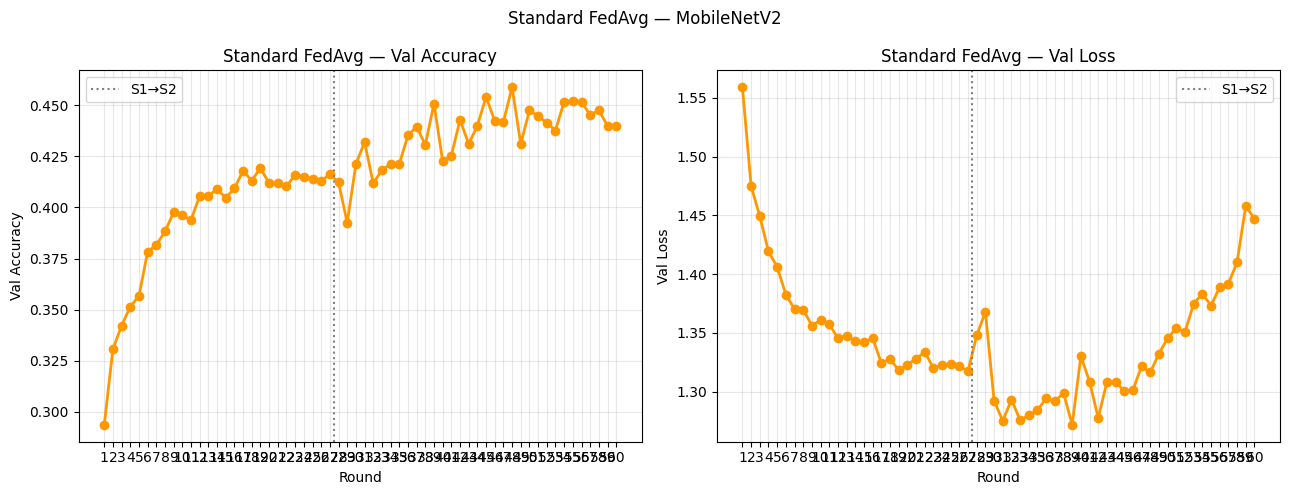

In [13]:
rounds   = [r["round"] for r in fl_logs]
val_acc  = [r["val_accuracy"] for r in fl_logs]
val_loss = [r["val_loss"] for r in fl_logs]
sb       = next((r for r,s in zip(rounds,[r["stage"] for r in fl_logs]) if s==2), None)

fig, ax = plt.subplots(1,2,figsize=(13,5))
for a, data, title in [(ax[0],val_acc,"Val Accuracy"),(ax[1],val_loss,"Val Loss")]:
    a.plot(rounds, data, marker="o", color="#FF9800", lw=2)
    if sb: a.axvline(sb-.5, color="gray", ls=":", lw=1.5, label="S1→S2"); a.legend()
    a.set_xlabel("Round"); a.set_ylabel(title); a.set_title(f"Standard FedAvg — {title}")
    a.grid(alpha=.3); a.set_xticks(rounds)
plt.suptitle(f"Standard FedAvg — {MODEL_NAME}"); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/fl_training_curves.png", dpi=300, bbox_inches="tight"); plt.show()

## 12. Predict Clean + Noisy

In [14]:
print("Predicting clean...")
yp_clean = gm.predict(test_clean, verbose=1)
yd_clean = np.argmax(yp_clean, 1)

print("Predicting noisy...")
yp_noisy = gm.predict(test_noisy, verbose=1)
yd_noisy = np.argmax(yp_noisy, 1)

Predicting clean...
67/67 ━━━━━━━━━━━━━━━━━━━━ 22s 263ms/step
Predicting noisy...
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


## 13. Metrics + Robustness Drop

In [15]:
def metrics(yt,yp,yprob):
    a = accuracy_score(yt,yp)
    p,r,f,_ = precision_recall_fscore_support(yt,yp,average="macro",zero_division=0)
    yb = label_binarize(yt,classes=np.arange(NUM_CLASSES))
    try: au = roc_auc_score(yb,yprob,multi_class="ovr",average="macro")
    except: au = float("nan")
    q = cohen_kappa_score(yt,yp,weights="quadratic")
    return dict(accuracy=float(a),precision_macro=float(p),recall_macro=float(r),
                f1_macro=float(f),auc_roc=float(au),qwk=float(q))

MKEYS = ["accuracy","precision_macro","recall_macro","f1_macro","auc_roc","qwk"]
mc = metrics(y_test, yd_clean, yp_clean)
mn = metrics(y_test, yd_noisy, yp_noisy)

print(f"{'Metric':<18} {'Clean':>8} {'Noisy':>8} {'Drop':>8}")
print("-"*44)
rob = {}
for k in MKEYS:
    d = mc[k]-mn[k]; rob[f"drop_{k}"] = float(d)
    print(f"{k:<18} {mc[k]:>8.4f} {mn[k]:>8.4f} {d:>+8.4f}")

Metric                Clean    Noisy     Drop
--------------------------------------------
accuracy             0.4499   0.3023  +0.1476
precision_macro      0.4439   0.2803  +0.1635
recall_macro         0.4495   0.2941  +0.1554
f1_macro             0.4446   0.2541  +0.1906
auc_roc              0.7648   0.5995  +0.1653
qwk                  0.6027   0.2081  +0.3947


## 14. Per-Class Metrics

In [16]:
def per_class(yt,yp):
    p,r,f,s = precision_recall_fscore_support(yt,yp,labels=np.arange(NUM_CLASSES),zero_division=0)
    return pd.DataFrame({"class":np.arange(NUM_CLASSES),"name":CLASS_NAMES,
                          "precision":p,"recall":r,"f1":f,"support":s})
pc_c = per_class(y_test,yd_clean); pc_n = per_class(y_test,yd_noisy)
print("CLEAN:"); print(pc_c.to_string(index=False))
print("\nNOISY:"); print(pc_n.to_string(index=False))
pc_c.to_csv(f"{LOG_DIR}/per_class_clean.csv",index=False)
pc_n.to_csv(f"{LOG_DIR}/per_class_noisy.csv",index=False)

CLEAN:
 class          name  precision   recall       f1  support
     0         No DR   0.560630 0.521230 0.540212      683
     1          Mild   0.346831 0.436807 0.386654      451
     2      Moderate   0.378313 0.307843 0.339459      510
     3        Severe   0.350467 0.384615 0.366748      195
     4 Proliferative   0.583051 0.597222 0.590051      288

NOISY:
 class          name  precision   recall       f1  support
     0         No DR   0.410959 0.351391 0.378848      683
     1          Mild   0.264151 0.031042 0.055556      451
     2      Moderate   0.268000 0.394118 0.319048      510
     3        Severe   0.190840 0.128205 0.153374      195
     4 Proliferative   0.267652 0.565972 0.363434      288


## 15. Per-Client Breakdown

In [17]:
print(f"{'Client':<10} {'N':>5}  {'Acc_C':>7} {'Acc_N':>7} {'Drop':>7}  {'F1_C':>6} {'F1_N':>6}  {'QWK_C':>7} {'QWK_N':>7}")
print("-"*78)
pcc = {}
for cl in CLIENT_NAMES:
    m = src_test==cl
    if not m.any(): continue
    mc_ = metrics(y_test[m],yd_clean[m],yp_clean[m])
    mn_ = metrics(y_test[m],yd_noisy[m],yp_noisy[m])
    pcc[cl] = {"n":int(m.sum()),"clean":mc_,"noisy":mn_}
    print(f"{cl:<10} {m.sum():>5,}  {mc_['accuracy']:>7.4f} {mn_['accuracy']:>7.4f} {mc_['accuracy']-mn_['accuracy']:>+7.4f}"
          f"  {mc_['f1_macro']:>6.4f} {mn_['f1_macro']:>6.4f}  {mc_['qwk']:>7.4f} {mn_['qwk']:>7.4f}")

Client         N    Acc_C   Acc_N    Drop    F1_C   F1_N    QWK_C   QWK_N
------------------------------------------------------------------------------
DDR          560   0.5071  0.3982 +0.1089  0.4373 0.3120   0.7145  0.3925
EyePACS    1,288   0.4115  0.2554 +0.1561  0.4166 0.2115   0.5052  0.0958
APTOS        279   0.5125  0.3262 +0.1864  0.4852 0.2762   0.6905  0.2127


## 16. Confusion Matrices

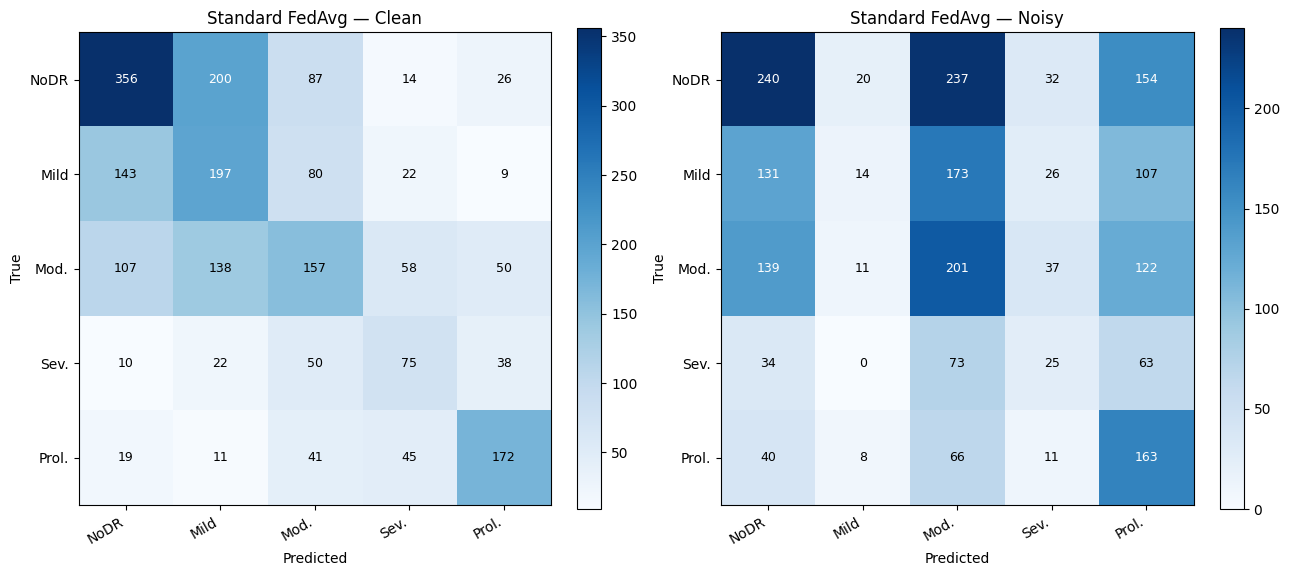

In [18]:
SN = ["NoDR","Mild","Mod.","Sev.","Prol."]
cm_c = confusion_matrix(y_test,yd_clean,labels=np.arange(NUM_CLASSES))
cm_n = confusion_matrix(y_test,yd_noisy,labels=np.arange(NUM_CLASSES))

fig,ax = plt.subplots(1,2,figsize=(13,6))
for a,cm,title in [(ax[0],cm_c,"Clean"),(ax[1],cm_n,"Noisy")]:
    im = a.imshow(cm,cmap="Blues"); plt.colorbar(im,ax=a,fraction=.046)
    a.set_xticks(range(NUM_CLASSES)); a.set_yticks(range(NUM_CLASSES))
    a.set_xticklabels(SN,rotation=30,ha="right"); a.set_yticklabels(SN)
    th = cm.max()/2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            a.text(j,i,str(cm[i,j]),ha="center",va="center",fontsize=9,color="white" if cm[i,j]>th else "black")
    a.set_xlabel("Predicted"); a.set_ylabel("True"); a.set_title(f"Standard FedAvg — {title}")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/confusion_matrices.png",dpi=300,bbox_inches="tight"); plt.show()

## 17. ROC Curves

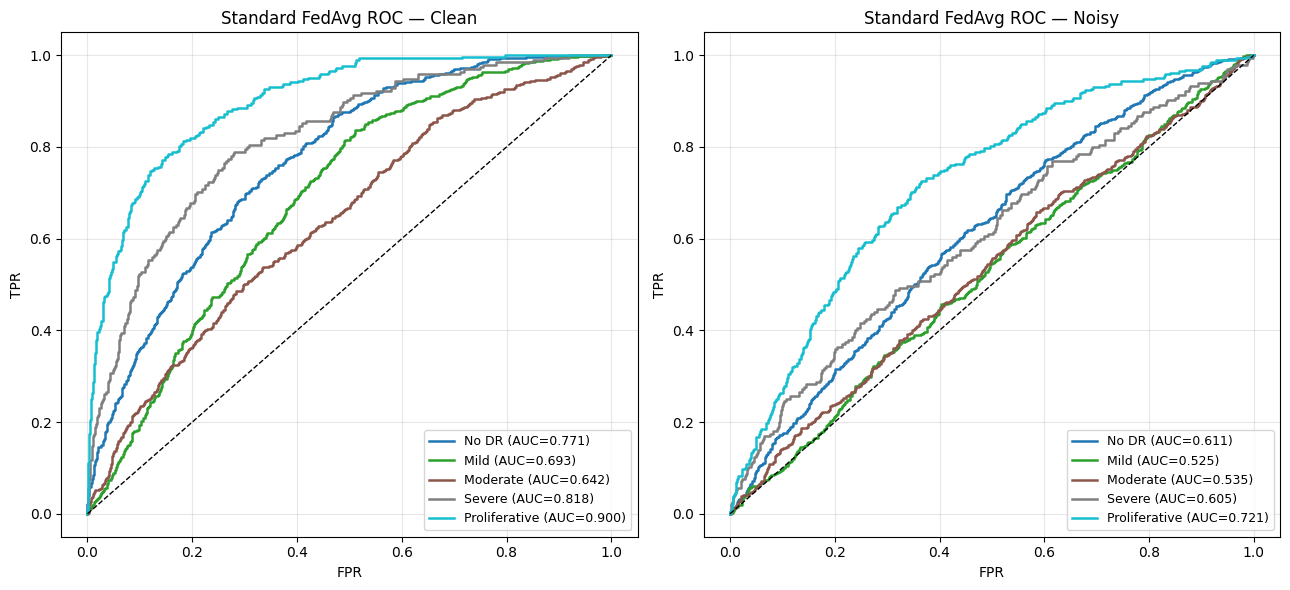

In [19]:
yb   = label_binarize(y_test, classes=np.arange(NUM_CLASSES))
COLS = plt.cm.tab10(np.linspace(0,1,NUM_CLASSES))
fig,ax = plt.subplots(1,2,figsize=(13,6))
for a,yprob,title in [(ax[0],yp_clean,"Clean"),(ax[1],yp_noisy,"Noisy")]:
    for i in range(NUM_CLASSES):
        fpr,tpr,_ = roc_curve(yb[:,i],yprob[:,i])
        a.plot(fpr,tpr,color=COLS[i],lw=1.8,label=f"{CLASS_NAMES[i]} (AUC={auc(fpr,tpr):.3f})")
    a.plot([0,1],[0,1],"k--",lw=1); a.set_xlabel("FPR"); a.set_ylabel("TPR")
    a.set_title(f"Standard FedAvg ROC — {title}"); a.legend(fontsize=9,loc="lower right"); a.grid(alpha=.3)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/roc_curves.png",dpi=300,bbox_inches="tight"); plt.show()

## 18. Robustness Drop Visualization

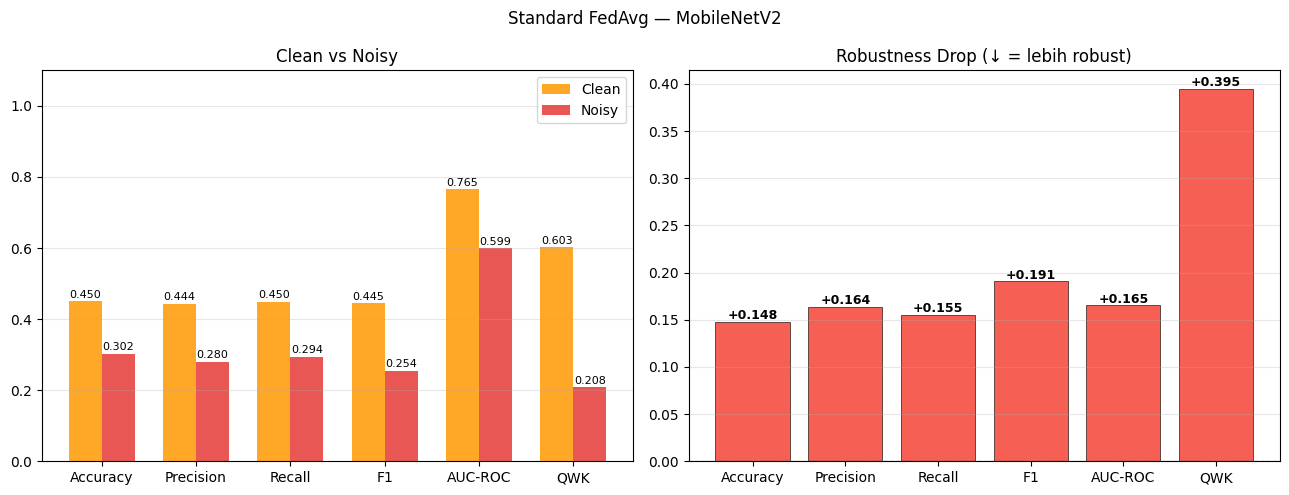

In [20]:
MLABELS = ["Accuracy","Precision","Recall","F1","AUC-ROC","QWK"]
cv=[mc[k] for k in MKEYS]; nv=[mn[k] for k in MKEYS]; dv=[rob[f"drop_{k}"] for k in MKEYS]
x=np.arange(len(MLABELS)); w=.35

fig,ax = plt.subplots(1,2,figsize=(13,5))
ax[0].bar(x-w/2,cv,w,label="Clean",color="#FF9800",alpha=.85)
ax[0].bar(x+w/2,nv,w,label="Noisy",color="#E53935",alpha=.85)
for i,(a_,b_) in enumerate(zip(cv,nv)):
    ax[0].text(i-w/2,a_+.01,f"{a_:.3f}",ha="center",fontsize=8)
    ax[0].text(i+w/2,b_+.01,f"{b_:.3f}",ha="center",fontsize=8)
ax[0].set_xticks(x); ax[0].set_xticklabels(MLABELS); ax[0].set_ylim(0,1.1)
ax[0].set_title("Clean vs Noisy"); ax[0].legend(); ax[0].grid(axis="y",alpha=.3)

clrs=["#4CAF50" if d<=.05 else "#FFC107" if d<=.1 else "#F44336" for d in dv]
ax[1].bar(x,dv,color=clrs,alpha=.85,edgecolor="black",lw=.5)
for i,d in enumerate(dv): ax[1].text(i,d+.003,f"{d:+.3f}",ha="center",fontsize=9,fontweight="bold")
ax[1].set_xticks(x); ax[1].set_xticklabels(MLABELS)
ax[1].set_title("Robustness Drop (↓ = lebih robust)"); ax[1].axhline(0,color="k",lw=.8,ls="--"); ax[1].grid(axis="y",alpha=.3)
plt.suptitle(f"Standard FedAvg — {MODEL_NAME}"); plt.tight_layout()
plt.savefig(f"{FIG_DIR}/robustness_drop.png",dpi=300,bbox_inches="tight"); plt.show()

## 19. Save Results + Summary

In [21]:
res = {
    "experiment":EXPERIMENT_NAME,"model":MODEL_NAME,"paradigm":"Standard FedAvg",
    "use_noise_aug":USE_NOISE_AUG,
    "client_sizes":dict(zip(CLIENT_NAMES,[int(s) for s in csz])),
    "n_test":int(len(y_test)),
    "metrics_clean":mc,"metrics_noisy":mn,"robustness_drop":rob,
    "per_client":pcc,
    "confusion_matrix_clean":cm_c.tolist(),"confusion_matrix_noisy":cm_n.tolist(),
    "config":dict(seed=SEED,noisy_test_seed=NOISY_TEST_SEED,batch=BATCH_SIZE,lr=LR,
                  fl_rounds=FL_ROUNDS,local_epochs=LOCAL_EPOCHS,
                  stage1_rounds=STAGE1_ROUNDS,unfreeze_n=UNFREEZE_N)
}
with open(f"{LOG_DIR}/results.json","w") as f: json.dump(res,f,indent=2)

row={"experiment":EXPERIMENT_NAME,"paradigm":"Standard FedAvg","model":MODEL_NAME}
row.update({f"clean_{k}":mc[k] for k in MKEYS})
row.update({f"noisy_{k}":mn[k] for k in MKEYS})
row.update(rob)
pd.DataFrame([row]).to_csv(f"{LOG_DIR}/summary_row.csv",index=False)
print(f"Saved to: {RES}")

print("\n"+"="*60)
print(f"  EXP2 STANDARD FEDAVG — DONE")
print("="*60)
print(f"  Clients: {CLIENT_NAMES}")
print(f"  CLEAN  | Acc:{mc['accuracy']:.4f}  F1:{mc['f1_macro']:.4f}  AUC:{mc['auc_roc']:.4f}  QWK:{mc['qwk']:.4f}")
print(f"  NOISY  | Acc:{mn['accuracy']:.4f}  F1:{mn['f1_macro']:.4f}  AUC:{mn['auc_roc']:.4f}  QWK:{mn['qwk']:.4f}")
print(f"  DROP   | Acc:{rob['drop_accuracy']:+.4f}  F1:{rob['drop_f1_macro']:+.4f}  AUC:{rob['drop_auc_roc']:+.4f}  QWK:{rob['drop_qwk']:+.4f}")
print("="*60)

Saved to: /content/drive/MyDrive/Binus/Semester_4/Research_Methodology/Result/MobileNetV2/exp2_fedavg

  EXP2 STANDARD FEDAVG — DONE
  Clients: ['DDR', 'EyePACS', 'APTOS']
  CLEAN  | Acc:0.4499  F1:0.4446  AUC:0.7648  QWK:0.6027
  NOISY  | Acc:0.3023  F1:0.2541  AUC:0.5995  QWK:0.2081
  DROP   | Acc:+0.1476  F1:+0.1906  AUC:+0.1653  QWK:+0.3947


In [22]:
# ── AUTO SHUTDOWN RUNTIME (Colab) ────────────────────────────────
import time

print("Training selesai. Runtime akan shutdown dalam 60 detik...")
print("Tekan Ctrl+C untuk batalkan.")

try:
    for i in range(60, 0, -5):
        print(f"  Shutdown dalam {i} detik...")
        time.sleep(5)
    from google.colab import runtime
    runtime.unassign()
except KeyboardInterrupt:
    print("Shutdown dibatalkan.")
except Exception as e:
    print(f"Colab runtime unassign gagal: {e}")
    # Fallback
    import subprocess
    subprocess.run(["kill", "-9", "-1"], check=False)

Training selesai. Runtime akan shutdown dalam 60 detik...
Tekan Ctrl+C untuk batalkan.
  Shutdown dalam 60 detik...
  Shutdown dalam 55 detik...
  Shutdown dalam 50 detik...
  Shutdown dalam 45 detik...
  Shutdown dalam 40 detik...
  Shutdown dalam 35 detik...
  Shutdown dalam 30 detik...
  Shutdown dalam 25 detik...
  Shutdown dalam 20 detik...
  Shutdown dalam 15 detik...
  Shutdown dalam 10 detik...
  Shutdown dalam 5 detik...
